In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df_ua = pd.read_csv('Ukraine.csv')

X = df_ua.drop(columns=['price', 'Unnamed: 0'])
y = df_ua['price']

In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Розмір навчальної вибірки: {X_train.shape[0]} квартир")
print(f"Розмір тестової вибірки: {X_test.shape[0]} квартир")

Розмір навчальної вибірки: 24319 квартир
Розмір тестової вибірки: 6080 квартир


In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

models_ua = {
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=63, random_state=42, verbose=-1),
    "CatBoost": CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=6, verbose=0, random_state=42)
}


results_ua = []

print("Тренуємо моделі для регіонів України...\n")

for name, model in models_ua.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results_ua.append({
        "Модель": name,
        "R2 Score": round(r2, 4),
        "MAE ($)": round(mae, 2),
        "RMSE ($)": round(rmse, 2)
    })
    
df_results_ua = pd.DataFrame(results_ua).sort_values(by="R2 Score", ascending=False).reset_index(drop=True)
print("ФІНАЛЬНІ РЕЗУЛЬТАТИ ПОРІВНЯННЯ ДЛЯ УКРАЇНИ:")
print(df_results_ua)

⏳ Тренуємо моделі для регіонів України... Поїхали!

ФІНАЛЬНІ РЕЗУЛЬТАТИ ПОРІВНЯННЯ ДЛЯ УКРАЇНИ:
             Модель  R2 Score  MAE ($)  RMSE ($)
0     Random Forest    0.7653   162.71    229.78
1          LightGBM    0.7626   167.43    231.08
2          CatBoost    0.7524   172.05    235.99
3  Ridge Regression    0.6288   221.19    288.95


In [5]:
from sklearn.model_selection import GridSearchCV

lgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.03, 0.05, 0.1],
    'num_leaves': [31, 63, 127],
    'max_depth': [-1, 10, 15],
    'random_state': [42]
}

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [15, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'random_state': [42],
    'n_jobs': [-1] 
}


print("=== Оптимізація LightGBM... ===")
lgb_grid = GridSearchCV(
    estimator=LGBMRegressor(),
    param_grid=lgb_param_grid,
    cv=3, 
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
lgb_grid.fit(X_train, y_train)

print("\n=== Оптимізація Random Forest... ===")
rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(),
    param_grid=rf_param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)

best_lgb = lgb_grid.best_estimator_
best_rf = rf_grid.best_estimator_

models = {
    'Optimized LightGBM': best_lgb,
    'Optimized Random Forest': best_rf
}

results = []

for name, model in models.items():
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    results.append({
        'Модель': name,
        'R2 Score': round(r2, 4),
        'MAE ($)': round(mae, 2),
        'RMSE ($)': round(rmse, 2)
    })

df_results = pd.DataFrame(results)
print("\n=== ФІНАЛЬНІ РЕЗУЛЬТАТИ ПІСЛЯ ТЮНІНГУ ===")
print(df_results.to_markdown(index=False))

print("\nНайкращі параметри LightGBM:", lgb_grid.best_params_)
print("Найкращі параметри Random Forest:", rf_grid.best_params_)

=== Оптимізація LightGBM... ===
Fitting 3 folds for each of 81 candidates, totalling 243 fits

=== Оптимізація Random Forest... ===
Fitting 3 folds for each of 36 candidates, totalling 108 fits

=== ФІНАЛЬНІ РЕЗУЛЬТАТИ ПІСЛЯ ТЮНІНГУ ===
| Модель                  |   R2 Score |   MAE ($) |   RMSE ($) |
|:------------------------|-----------:|----------:|-----------:|
| Optimized LightGBM      |     0.7787 |    159.14 |     223.12 |
| Optimized Random Forest |     0.78   |    153.46 |     222.45 |

Найкращі параметри LightGBM: {'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 300, 'num_leaves': 127, 'random_state': 42}
Найкращі параметри Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300, 'n_jobs': -1, 'random_state': 42}


In [6]:
import joblib

final_rf_model = rf_grid.best_estimator_

model_filename = 'optimized_random_forest_ukraine_model.pkl'
joblib.dump(final_rf_model, model_filename, compress=3)

print(f"Модель Random Forest успішно збережено у файл: {model_filename}")

Модель Random Forest успішно збережено у файл: optimized_random_forest_ukraine_model.pkl


🎯 Сформовано ТОП-15 найважливіших ознак для України:
['is_tourist_hub', 'year_of_building', 'freshly_renovated_True', 'area', 'kitchen_area', 'is_modern_fund', 'city_Lviv', 'floor', 'district_Outskirts', 'geo_region_South', 'city_Zaporizhzhia', 'num_of_rooms', 'is_high_floor', 'district_Residential', 'city_Kharkiv']

=== 📊 МЕТРИКИ ФІНАЛЬНОЇ МОДЕЛІ (15 ФІЧ) ===
R2 Score: 0.7329
MAE ($):  172.75
RMSE ($): 245.12



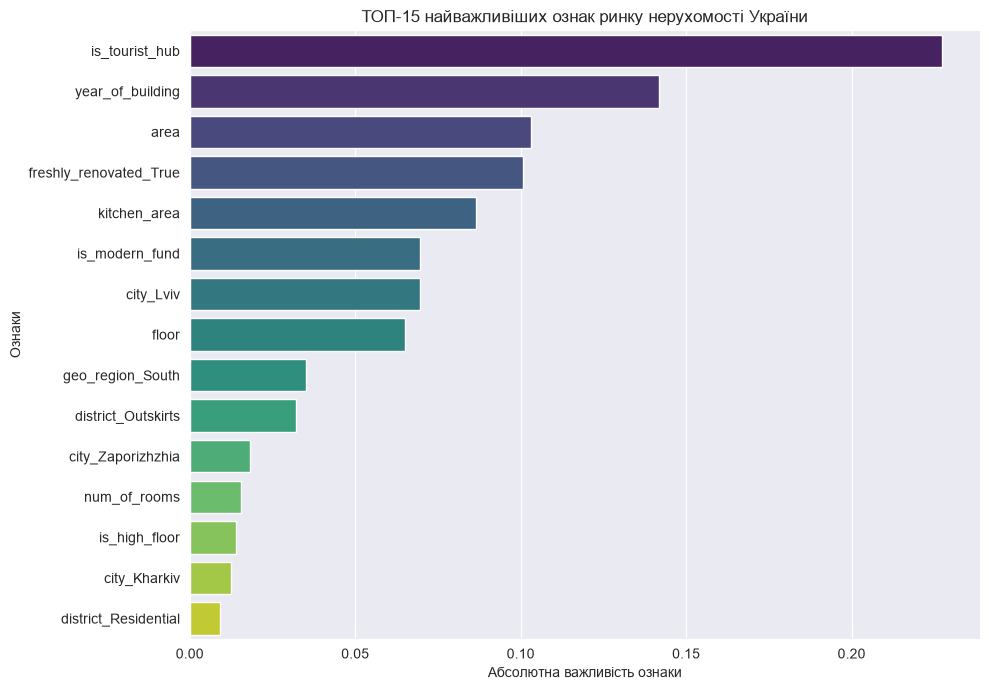

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

expert_drop = ['living_area', 'floors_in_house', 'is_middle_floor']
X_train_step1 = X_train.drop(columns=[col for col in expert_drop if col in X_train.columns])

rf_selector = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train_step1, y_train)

importances = rf_selector.feature_importances_
all_features = X_train_step1.columns
top_15_features = pd.Series(importances, index=all_features).sort_values(ascending=False).head(15).index.tolist()

print(f"🎯 Сформовано ТОП-15 найважливіших ознак для України:\n{top_15_features}\n")

X_train_top15 = X_train_step1[top_15_features]
X_test_top15 = X_test[top_15_features]


rf_final_15 = RandomForestRegressor(
    n_estimators=300, 
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_final_15.fit(X_train_top15, y_train)

preds_15 = rf_final_15.predict(X_test_top15)
final_r2 = r2_score(y_test, preds_15)
final_mae = mean_absolute_error(y_test, preds_15)
final_rmse = np.sqrt(mean_squared_error(y_test, preds_15))

print(f"=== 📊 МЕТРИКИ ФІНАЛЬНОЇ МОДЕЛІ (15 ФІЧ) ===")
print(f"R2 Score: {final_r2:.4f}")
print(f"MAE ($):  {final_mae:.2f}")
print(f"RMSE ($): {final_rmse:.2f}\n")


final_importances = pd.Series(rf_final_15.feature_importances_, index=top_15_features).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(
    x=final_importances.values, 
    y=final_importances.index, 
    hue=final_importances.index, 
    palette="viridis", 
    legend=False
)
plt.title("ТОП-15 найважливіших ознак ринку нерухомості України")
plt.xlabel("Абсолютна важливість ознаки")
plt.ylabel("Ознаки")
plt.tight_layout()
plt.show()